In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import pearsonr


# MVS 5/13/26 "please correlate allBC pairs for an AD at a single time point"

In [4]:
ChopTFs = pd.read_csv("../../output/ChopTFs_pipeline/trebl_experiment_activities_per_barcode.csv", index_col = 0)
ChopTFs

,AD,AD_end,AD_BC,RPTR_BC,count_simple_AD,count_directional_AD,rep,time,count_simple_RT,count_directional_RT,activity_simple,activity_directional,AD_protein
0,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,177.0,175.0,2,0,11.0,11.0,-1.206581,-1.201645,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
1,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,186.0,182.0,2,2,14.0,14.0,-1.123385,-1.113943,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
2,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,166.0,164.0,2,5,10.0,8.0,-1.220108,-1.311754,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
3,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,232.0,231.0,2,10,34.0,33.0,-0.834009,-0.845098,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
4,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,243.0,241.0,2,15,70.0,65.0,-0.540508,-0.569104,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1827292,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,74.0,73.0,4,20,10.0,9.0,-0.869232,-0.909080,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827293,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,87.0,86.0,4,30,16.0,14.0,-0.735399,-0.788370,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827294,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,96.0,95.0,4,40,16.0,16.0,-0.778151,-0.773604,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827295,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,108.0,108.0,4,50,28.0,27.0,-0.586266,-0.602060,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR


In [21]:
# --- Parameters ---
TIME_POINT = 30          # pick one time point
ACTIVITY_COL = 'activity_directional'
MIN_BC_PAIRS = 2        # only ADs with at least this many BC pairs 
REP = 2

In [22]:
# --- Filter to single time point ---
df_t = ChopTFs[ChopTFs['time'] == TIME_POINT].copy()
df_t = df_t[df_t["rep"] == REP]

# --- Create a unique barcode pair label ---
df_t['BC_pair'] = df_t['AD_BC'] + '_' + df_t['RPTR_BC']

In [23]:
# --- Number the BC pairs within each AD (arbitrary but consistent) ---
df_t['bc_rank'] = df_t.groupby('AD_protein')['BC_pair'].transform(
    lambda x: pd.factorize(x)[0] + 1  # 1, 2, 3...
)

# --- Pivot: rows = AD, columns = bc_rank ---
pivot = df_t.pivot_table(
    index='AD_protein',
    columns='bc_rank',
    values=ACTIVITY_COL,
    aggfunc='mean'
)

In [24]:
# --- Correlate pair 1 vs pair 2 (most ADs will have at least 2) ---
pair_data = pivot[[1, 2]].dropna()
r, p = pearsonr(pair_data[1], pair_data[2])

print(f"n ADs with ≥2 BC pairs: {len(pair_data)}")
print(f"Pearson r = {r:.4f}, p = {p:.2e}")

n ADs with ≥2 BC pairs: 12136
Pearson r = 0.6283, p = 0.00e+00


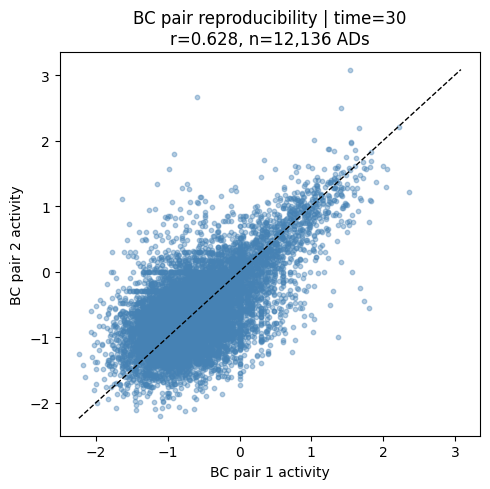

In [25]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(pair_data[1], pair_data[2], alpha=0.4, s=10, color='steelblue')
lims = [min(pair_data.min().min(), pair_data.min().min()),
        max(pair_data.max().max(), pair_data.max().max())]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlabel('BC pair 1 activity')
ax.set_ylabel('BC pair 2 activity')
ax.set_title(f'BC pair reproducibility | time={TIME_POINT}\nr={r:.3f}, n={len(pair_data):,} ADs')
plt.tight_layout()
plt.show()

In [8]:
ChopTFs_t30 = ChopTFs[ChopTFs["time"] == 30]
ChopTFs_t30

,AD,AD_end,AD_BC,RPTR_BC,count_simple_AD,count_directional_AD,rep,time,count_simple_RT,count_directional_RT,activity_simple,activity_directional,AD_protein
6,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,239.0,239.0,2,30,106.0,102.0,-0.353092,-0.369798,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
16,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,175.0,173.0,3,30,53.0,48.0,-0.518762,-0.556805,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
26,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,189.0,185.0,4,30,76.0,68.0,-0.395648,-0.434663,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
36,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,TATCTTCGCTT,CCCTCACCCGATTA,65.0,64.0,2,30,15.0,15.0,-0.636822,-0.630089,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
46,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,TATCTTCGCTT,CCCTCACCCGATTA,33.0,33.0,3,30,13.0,12.0,-0.404571,-0.439333,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1827252,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,GATCCCATGCA,CTCTGCTACTTGTG,68.0,66.0,3,30,15.0,15.0,-0.656418,-0.643453,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827262,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,GATCCCATGCA,CTCTGCTACTTGTG,111.0,110.0,4,30,23.0,20.0,-0.683595,-0.740363,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827273,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,70.0,69.0,2,30,9.0,7.0,-0.890856,-0.993751,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827283,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,102.0,102.0,3,30,19.0,17.0,-0.729847,-0.778151,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR


In [9]:
ChopTFs_t30_r2 = ChopTFs_t30[ChopTFs_t30["rep"] == 2]
ChopTFs_t30_r2

,AD,AD_end,AD_BC,RPTR_BC,count_simple_AD,count_directional_AD,rep,time,count_simple_RT,count_directional_RT,activity_simple,activity_directional,AD_protein
6,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,239.0,239.0,2,30,106.0,102.0,-0.353092,-0.369798,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
36,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,TATCTTCGCTT,CCCTCACCCGATTA,65.0,64.0,2,30,15.0,15.0,-0.636822,-0.630089,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
66,AAAAATTCTAAGAGACAGAAATCTTCTACTTATACTTCTCAAACTT...,AATCTTGTCTAATTTGGCTTCATTCTATAATACTCATGGT,AATCGTACCGA,TTTGATATCCAAAC,35.0,34.0,2,30,7.0,6.0,-0.698970,-0.753328,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG
99,AAAAATTCTAAGAGACAGAAATCTTCTACTTATACTTCTCAAACTT...,AATCTTGTCTAATTTGGCTTCATTCTATAATACTCATGGT,TTGCATAGCTG,TATTGTTCTCTGCT,80.0,78.0,2,30,12.0,11.0,-0.823909,-0.850702,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG
129,AAAAATTCTAAGAGACAGAAATCTTCTACTTATACTTCTCAAACTT...,AATCTTGTCTAATTTGGCTTCATTCTATAATACTCATGGT,TTTATAATACC,CATCGAACCTGAAC,178.0,177.0,2,30,28.0,25.0,-0.803262,-0.850033,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1827152,TTTGTTTCTTTGTTGGATACTCCATCTAAGAAATCTGATTCTAAAT...,ACATCCTAAAGTTTCTAATATGTCTGGATTCTTGGCTGGT,GAAAGGACAGA,CATATAGCTGGTAA,7.0,7.0,2,30,3.0,3.0,-0.367977,-0.367977,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG
1827172,TTTGTTTCTTTGTTGGATACTCCATCTAAGAAATCTGATTCTAAAT...,ACATCCTAAAGTTTCTAATATGTCTGGATTCTTGGCTGGT,GGGTCGTAAAT,CAACAGCCCTTACG,15.0,15.0,2,30,3.0,3.0,-0.698970,-0.698970,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG
1827210,TTTGTTTCTTTGTTGGATACTCCATCTAAGAAATCTGATTCTAAAT...,ACATCCTAAAGTTTCTAATATGTCTGGATTCTTGGCTGGT,TCTTCCTGAAT,TATGATAATGTGTA,21.0,21.0,2,30,7.0,6.0,-0.477121,-0.544068,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG
1827242,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,GATCCCATGCA,CTCTGCTACTTGTG,101.0,101.0,2,30,28.0,22.0,-0.557163,-0.661899,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR


In [10]:
ChopTFs_t30_r2["bc_pair"] = ChopTFs_t30_r2["AD_BC"] + ChopTFs_t30_r2["RPTR_BC"]
ChopTFs_t30_r2

/tmp/ipykernel_226309/2675926388.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ChopTFs_t30_r2["bc_pair"] = ChopTFs_t30_r2["AD_BC"] + ChopTFs_t30_r2["RPTR_BC"]


,AD,AD_end,AD_BC,RPTR_BC,count_simple_AD,count_directional_AD,rep,time,count_simple_RT,count_directional_RT,activity_simple,activity_directional,AD_protein,bc_pair
6,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,239.0,239.0,2,30,106.0,102.0,-0.353092,-0.369798,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,ATAACCAATGGTGAGAGAAAATCTA
36,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,TATCTTCGCTT,CCCTCACCCGATTA,65.0,64.0,2,30,15.0,15.0,-0.636822,-0.630089,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,TATCTTCGCTTCCCTCACCCGATTA
66,AAAAATTCTAAGAGACAGAAATCTTCTACTTATACTTCTCAAACTT...,AATCTTGTCTAATTTGGCTTCATTCTATAATACTCATGGT,AATCGTACCGA,TTTGATATCCAAAC,35.0,34.0,2,30,7.0,6.0,-0.698970,-0.753328,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,AATCGTACCGATTTGATATCCAAAC
99,AAAAATTCTAAGAGACAGAAATCTTCTACTTATACTTCTCAAACTT...,AATCTTGTCTAATTTGGCTTCATTCTATAATACTCATGGT,TTGCATAGCTG,TATTGTTCTCTGCT,80.0,78.0,2,30,12.0,11.0,-0.823909,-0.850702,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,TTGCATAGCTGTATTGTTCTCTGCT
129,AAAAATTCTAAGAGACAGAAATCTTCTACTTATACTTCTCAAACTT...,AATCTTGTCTAATTTGGCTTCATTCTATAATACTCATGGT,TTTATAATACC,CATCGAACCTGAAC,178.0,177.0,2,30,28.0,25.0,-0.803262,-0.850033,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,TTTATAATACCCATCGAACCTGAAC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1827152,TTTGTTTCTTTGTTGGATACTCCATCTAAGAAATCTGATTCTAAAT...,ACATCCTAAAGTTTCTAATATGTCTGGATTCTTGGCTGGT,GAAAGGACAGA,CATATAGCTGGTAA,7.0,7.0,2,30,3.0,3.0,-0.367977,-0.367977,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,GAAAGGACAGACATATAGCTGGTAA
1827172,TTTGTTTCTTTGTTGGATACTCCATCTAAGAAATCTGATTCTAAAT...,ACATCCTAAAGTTTCTAATATGTCTGGATTCTTGGCTGGT,GGGTCGTAAAT,CAACAGCCCTTACG,15.0,15.0,2,30,3.0,3.0,-0.698970,-0.698970,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,GGGTCGTAAATCAACAGCCCTTACG
1827210,TTTGTTTCTTTGTTGGATACTCCATCTAAGAAATCTGATTCTAAAT...,ACATCCTAAAGTTTCTAATATGTCTGGATTCTTGGCTGGT,TCTTCCTGAAT,TATGATAATGTGTA,21.0,21.0,2,30,7.0,6.0,-0.477121,-0.544068,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,TCTTCCTGAATTATGATAATGTGTA
1827242,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,GATCCCATGCA,CTCTGCTACTTGTG,101.0,101.0,2,30,28.0,22.0,-0.557163,-0.661899,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,GATCCCATGCACTCTGCTACTTGTG


In [11]:
pivot = ChopTFs_t30_r2.pivot_table(
    index="AD",
    columns="bc_pair",
    values="activity_directional"
)
pivot

bc_pair,AAAAAAAACAAGTTTGTCTGCTCTC,AAAAAAAACACTTAATACATTATAC,AAAAAAACAAGAAATGAAATAACAA,AAAAAAACACGGTTCTATTGTGACA,AAAAAAACAGCCCGGCTGATAGTAT,AAAAAAACTTCTGGATAAAGTGTGT,AAAAAAAGGAATCCCAAATTCAGAG,AAAAAAAGTATGCACCTAACATGTA,AAAAAAATAACTCATGGCATGACGT,AAAAAAATACCTTCCACGGGATGTA,...,TTTTTTGGCGCTAGCAATTAAAGTA,TTTTTTGGGGCCGACCATTTGATTG,TTTTTTGTACCTCATATAAAACGGT,TTTTTTGTCATATACACCCAGTTTC,TTTTTTGTCTTAGCAATGTGAGAAG,TTTTTTTAGGTAAGAGTAATAAAAG,TTTTTTTCGCTATAAAAAATTGACA,TTTTTTTGTCTTGTGTTATTGCATG,TTTTTTTGTTATGATACTATTTGGC,TTTTTTTTGTTTATCCCCCCTTGGA
AD,,,,,,,,,,,,,,,,,,,,,
AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATTATGCTATGGCTAATTATTTGAATAATACTCCAATTTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAAAATTCTAAGAGACAGAAATCTTCTACTTATACTTCTCAAACTTCTTCTCCAATTGGTCCAAGAGATCCAACTGTTCAAATCTTGTCTAATTTGGCTTCATTCTATAATACTCATGGT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAAAATTCTATTTCTAGGAAAAATTCTGCTGTTACTACTGCTCCAGCTCAGAAAGATGATGTTGAGAATAATAAGATTTCTAATAATGTTACTTTGGATGAGAATGAAGAACAAGAAAGA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAAAATTCTCATTCTGTTATTTCTTCTAGAAGATCTTCATTTAATATGATGCATTCTAGAAGATCTTCATTTAATTCTCATGCTCCAACTGAACCAATTTCTAGAAGAGCTTCTTTGGTT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAAAATTCTGAAATTAATTACTTCTTCTCTGCTATGGCTAATAATACTAAGATCTTGTTTAGAATCTTCTTTCCATTGTCTTCTGTTACTAATTGTTCTTTGACTTTGGAAACTGATGAT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTTCTATCTTGGTTATTGCTGGTTATATGAGAAGATTGGAAGACTTTGCTCAGAATAAAAATTCTGATTGTATGATTGGTTCTTTGAAATCTACTGATAGAATCTTGTGGTTGAAA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TTTGTTTCTCCATTTACTGCTGCTGCTACTACTTCTGTTACTACTAAGACTGTTAAAGATACTACTCCAGCTACTAATCATATGGATGATGATATTGCTATGTTTGATTCTTTGGCTACT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TTTGTTTCTGGTGATGATGGTTCTAATTCTAAGACTAAGAATTTGGATTCTAATATGTTCTCTAATGACTTTAACTTTGAGAATCAATTTGATGAACAAGTTTCTGAGTTCTGTTCTAAA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
GCN4 = pd.read_csv("../../output/GCN4_pipeline/trebl_experiment_pool_C_umi_results_per_barcode.csv", index_col = 0)
GCN4

,AD,AD_BC,RPTR_BC,rep,time,count_simple_AD,count_directional_AD,count_simple_RT,count_directional_RT,activity_simple,activity_directional
0,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,GCATATAGAGA,CCTGCTATTCGTAA,1,10,106,98,80,51,-0.281412,-0.653142
1,TCTAATACTCAAGCTGTTACTGGTCAACATAGAAGACATTCTTCTA...,CCACAGACGGA,TACCTCCGACTGTC,1,10,106,103,6,5,-2.871680,-3.025291
2,GCTGAAATTAGAGGTGGTACTAGATTGGTTTGTAGAAGAGAGAATG...,CAGACCAAGAA,GTGGTCAAGGCTCG,1,10,106,103,12,8,-2.178532,-2.555287
3,GAAGTTGGTGACTTCTCTGTTAATAAACCACCACAAGCTGATGATA...,ATTTGTACTAG,CCATGTTTGGCGAA,1,10,106,102,7,6,-2.717529,-2.833213
4,TTGGCTTCTCCACATTTGTTGTTGGTTAATGTTCATTGTCATGAAC...,AACGTTCCTCA,ATATAAAGCGATTG,1,10,106,100,10,8,-2.360854,-2.525729
...,...,...,...,...,...,...,...,...,...,...,...
342856,TCTGGTCATCAAGTTGTTAATTCTTCTTCTTTGAATATTCCAAGAG...,GGATATTACAC,TCTTAAAGGTCAGA,1,30,46,43,23,16,-0.693147,-0.988611
342857,ACTAATACTGCTCCAACTACATTTACTTCTGGTTTGTGTTCTTCTT...,GATAAGACTAC,CCCAATCCCCGGCG,1,30,46,46,3,2,-2.730029,-3.135494
342858,GAAGAAGAAACTAAAGCTGCTGAACCAAATTATGGTTCTGTTGCTA...,ATACGAGAGGT,CACGCTTAGGATAT,1,30,46,43,3,3,-2.730029,-2.662588
342859,TCTTCTTCTTCTTCTCCAAATAACTTTGCTCCAATTGACTTTACTT...,TCTCATATAAT,CTTGTAGTGGCGGC,1,30,46,42,36,25,-0.245122,-0.518794
